### Load `mortgage.csv` from Google Drive

First, we need to mount Google Drive to access your files. Then we will load the `mortgage.csv` file into a DataFrame and replace the existing `raw` DataFrame.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Replace 'path/to/your/mortgage.csv' with the actual path to your file in Google Drive
# For example: '/content/drive/MyDrive/mortgage.csv'
mortgage_file_path = '/content/drive/MyDrive/mortgage.csv' # Adjust this path as needed

try:
    raw = pd.read_csv(mortgage_file_path)
    print(f"Successfully loaded '{mortgage_file_path}' into the 'raw' DataFrame.")
    print("Displaying the first 5 rows of the new 'raw' DataFrame:")
    display(raw.head())
except FileNotFoundError:
    print(f"Error: The file '{mortgage_file_path}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Successfully loaded '/content/drive/MyDrive/mortgage.csv' into the 'raw' DataFrame.
Displaying the first 5 rows of the new 'raw' DataFrame:


,id,time,orig_time,first_time,mat_time,balance_time,LTV_time,interest_rate_time,hpi_time,gdp_time,...,REtype_SF_orig_time,investor_orig_time,balance_orig_time,FICO_orig_time,LTV_orig_time,Interest_Rate_orig_time,hpi_orig_time,default_time,payoff_time,status_time
0,1,25,-7,25,113,41303.42,24.498336,9.2,226.29,2.899137,...,1,0,45000.0,715,69.4,9.2,87.03,0,0,0
1,1,26,-7,25,113,41061.95,24.483867,9.2,225.10,2.151365,...,1,0,45000.0,715,69.4,9.2,87.03,0,0,0
2,1,27,-7,25,113,40804.42,24.626795,9.2,222.39,2.361722,...,1,0,45000.0,715,69.4,9.2,87.03,0,0,0
3,1,28,-7,25,113,40483.89,24.735883,9.2,219.67,1.229172,...,1,0,45000.0,715,69.4,9.2,87.03,0,0,0
4,1,29,-7,25,113,40367.06,24.925476,9.2,217.37,1.692969,...,1,0,45000.0,715,69.4,9.2,87.03,0,0,0


### Data Preparation for `mortgage.csv`

With the `mortgage.csv` loaded into the `raw` DataFrame, we need to perform data preparation steps tailored to this dataset. This includes:

1.  **Dropping unnecessary columns**: The `id` column is an identifier and not useful for modeling.
2.  **Defining Features (X) and Target (y)**: We will use `default_time` as our target variable for classification. `payoff_time` and `status_time` are highly correlated with `default_time` and could lead to data leakage, so we will exclude them from features.
3.  **Splitting Data**: Dividing the dataset into training and testing sets.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb

# Drop the 'id' column as it's an identifier and not a feature
if 'id' in raw.columns:
    raw = raw.drop(columns=['id'])
    print("Dropped 'id' column.")

# Define target variable (y) and features (X)
# 'default_time' is likely a binary indicator of default
# 'payoff_time' and 'status_time' are highly correlated with default and should be excluded as features to avoid data leakage

target_column = 'default_time'

if target_column not in raw.columns:
    print(f"Error: Target column '{target_column}' not found in DataFrame. Please check the available columns.")
else:
    # Separate features (X) and target (y)
    # Exclude target-related columns that might cause data leakage (e.g., 'payoff_time', 'status_time')
    columns_to_exclude = [target_column, 'payoff_time', 'status_time']
    X = raw.drop(columns=[col for col in columns_to_exclude if col in raw.columns])
    y = raw[target_column]

    print(f"Features (X) shape: {X.shape}")
    print(f"Target (y) shape: {y.shape}")

    # Display the first few rows of features and target
    print("\nFeatures (X) head:")
    display(X.head())
    print("\nTarget (y) head:")
    display(y.head())

Dropped 'id' column.
Features (X) shape: (622489, 19)
Target (y) shape: (622489,)

Features (X) head:


,time,orig_time,first_time,mat_time,balance_time,LTV_time,interest_rate_time,hpi_time,gdp_time,uer_time,REtype_CO_orig_time,REtype_PU_orig_time,REtype_SF_orig_time,investor_orig_time,balance_orig_time,FICO_orig_time,LTV_orig_time,Interest_Rate_orig_time,hpi_orig_time
0,25,-7,25,113,41303.42,24.498336,9.2,226.29,2.899137,4.7,0,0,1,0,45000.0,715,69.4,9.2,87.03
1,26,-7,25,113,41061.95,24.483867,9.2,225.10,2.151365,4.7,0,0,1,0,45000.0,715,69.4,9.2,87.03
2,27,-7,25,113,40804.42,24.626795,9.2,222.39,2.361722,4.4,0,0,1,0,45000.0,715,69.4,9.2,87.03
3,28,-7,25,113,40483.89,24.735883,9.2,219.67,1.229172,4.6,0,0,1,0,45000.0,715,69.4,9.2,87.03
4,29,-7,25,113,40367.06,24.925476,9.2,217.37,1.692969,4.5,0,0,1,0,45000.0,715,69.4,9.2,87.03



Target (y) head:


,default_time
0,0
1,0
2,0
3,0
4,0


### Split Data into Training and Testing Sets

Now we will split the features and target into training and testing sets. A common split is 80% for training and 20% for testing, but this can be adjusted.

In [ ]:
# Split the data into training and testing sets
# We'll use a 80/20 split, but you can adjust `test_size` as needed
# `random_state` ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (497991, 19)
X_test shape: (124498, 19)
y_train shape: (497991,)
y_test shape: (124498,)


### Initialize and Train XGBoost Classifier

Now that our data is prepared and split, we can initialize and train an XGBoost classifier. We will use default parameters for now, which can be tuned later for better performance. Since `default_time` is likely a binary target (0 or 1), we will use `objective='binary:logistic'` and `eval_metric='logloss'`.

In [ ]:
# Calculate scale_pos_weight for handling class imbalance
# It's the ratio of the number of negative samples to the number of positive samples
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

# Initialize the XGBoost Classifier with scale_pos_weight
# 'objective="binary:logistic"' for binary classification
# 'eval_metric="logloss"' is a common metric for binary classification
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Deprecated parameter, can be removed in newer versions of XGBoost
    random_state=42,
    scale_pos_weight=scale_pos_weight_value # Add this parameter for imbalanced datasets
)

# Train the model
print("\nTraining the XGBoost model with updated class weights...")
model.fit(X_train, y_train)
print("XGBoost model training complete!")

Calculated scale_pos_weight: 40.27

Training the XGBoost model with updated class weights...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:09:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training complete!


In [ ]:
import pandas as pd

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Get feature names from X_train
feature_names = X_train.columns

# Create a DataFrame to display feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances (Top 10):")
display(importance_df.head(10))

print("\nFeature Importances (Bottom 10):")
display(importance_df.tail(10))

Feature Importances (Top 10):


,Feature,Importance
5,LTV_time,0.149596
6,interest_rate_time,0.127859
0,time,0.065972
15,FICO_orig_time,0.063482
4,balance_time,0.053979
3,mat_time,0.049599
8,gdp_time,0.047335
16,LTV_orig_time,0.047076
9,uer_time,0.044236
14,balance_orig_time,0.039195



Feature Importances (Bottom 10):


,Feature,Importance
14,balance_orig_time,0.039195
12,REtype_SF_orig_time,0.038913
17,Interest_Rate_orig_time,0.038903
13,investor_orig_time,0.036842
1,orig_time,0.036581
7,hpi_time,0.036253
10,REtype_CO_orig_time,0.033106
18,hpi_orig_time,0.032739
2,first_time,0.030276
11,REtype_PU_orig_time,0.028056


### Correlation Analysis with `LTV_time`

Given `LTV_time` was identified as the most important feature, let's perform a correlation analysis to understand its relationship with other variables in the dataset. We'll calculate the Pearson correlation coefficient between `LTV_time` and all other features.

In [ ]:
import pandas as pd

# Ensure 'LTV_time' is in X before attempting correlation
if 'LTV_time' in X.columns:
    # Calculate correlations with LTV_time
    ltv_time_correlations = X.corrwith(X['LTV_time'])

    # Drop the self-correlation of LTV_time with itself
    ltv_time_correlations = ltv_time_correlations.drop('LTV_time')

    # Convert to DataFrame for better display
    correlation_df = ltv_time_correlations.to_frame(name='Correlation with LTV_time')

    # Sort by absolute correlation value to see strongest relationships
    correlation_df['Absolute Correlation'] = correlation_df['Correlation with LTV_time'].abs()
    correlation_df = correlation_df.sort_values(by='Absolute Correlation', ascending=False)

    print("Correlations with 'LTV_time' (sorted by absolute value):")
    display(correlation_df)
else:
    print("'LTV_time' column not found in the features DataFrame (X).")

Correlations with 'LTV_time' (sorted by absolute value):


,Correlation with LTV_time,Absolute Correlation
hpi_orig_time,0.668554,0.668554
orig_time,0.612543,0.612543
mat_time,0.522548,0.522548
hpi_time,-0.446349,0.446349
uer_time,0.434144,0.434144
LTV_orig_time,0.397982,0.397982
first_time,0.374652,0.374652
gdp_time,-0.346116,0.346116
time,0.277279,0.277279
balance_time,0.113582,0.113582


In [ ]:
prev_importance_df = importance_df.copy()
print("Current feature importance data stored as 'prev_importance_df'.")

Current feature importance data stored as 'prev_importance_df'.


### Retraining XGBoost without `interest_rate_time`

As requested, I will now exclude the `interest_rate_time` feature, re-prepare the data, and retrain the XGBoost model. This will allow us to observe how feature importances change without this particular variable.

In [ ]:
# Exclude 'interest_rate_time' from features
# Re-define features (X) and target (y)
# Make sure to start with the original 'raw' DataFrame to avoid cumulative exclusions

target_column = 'default_time'
columns_to_exclude_new = [target_column, 'payoff_time', 'status_time', 'interest_rate_time']

X_new = raw.drop(columns=[col for col in columns_to_exclude_new if col in raw.columns])
y_new = raw[target_column]

print(f"New Features (X_new) shape: {X_new.shape}")
print(f"Target (y_new) shape: {y_new.shape}")

# Split the new data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

print(f"X_train_new shape: {X_train_new.shape}")
print(f"X_test_new shape: {X_test_new.shape}")
print(f"y_train_new shape: {y_train_new.shape}")
print(f"y_test_new shape: {y_test_new.shape}")

New Features (X_new) shape: (622489, 18)
Target (y_new) shape: (622489,)
X_train_new shape: (497991, 18)
X_test_new shape: (124498, 18)
y_train_new shape: (497991,)
y_test_new shape: (124498,)


In [ ]:
# Calculate scale_pos_weight for handling class imbalance with the new training data
neg_count_new = y_train_new.value_counts()[0]
pos_count_new = y_train_new.value_counts()[1]
scale_pos_weight_value_new = neg_count_new / pos_count_new

print(f"Calculated new scale_pos_weight: {scale_pos_weight_value_new:.2f}")

# Initialize and train the new XGBoost Classifier
model_new = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight_value_new
)

print("\nTraining the new XGBoost model without 'interest_rate_time'...")
model_new.fit(X_train_new, y_train_new)
print("New XGBoost model training complete!")

Calculated new scale_pos_weight: 40.27

Training the new XGBoost model without 'interest_rate_time'...
New XGBoost model training complete!


### New Feature Importances

Now, let's examine the feature importances from the retrained model (without `interest_rate_time`).

In [ ]:
# Get feature importances from the new trained model
feature_importances_new = model_new.feature_importances_

# Get feature names from X_train_new
feature_names_new = X_train_new.columns

# Create a DataFrame to display new feature importances
importance_df_new = pd.DataFrame({
    'Feature': feature_names_new,
    'Importance': feature_importances_new
})

# Sort by importance in descending order
importance_df_new = importance_df_new.sort_values(by='Importance', ascending=False)

print("New Feature Importances (Top 10):")
display(importance_df_new.head(10))

New Feature Importances (Top 10):


,Feature,Importance
5,LTV_time,0.151906
14,FICO_orig_time,0.097366
0,time,0.083894
16,Interest_Rate_orig_time,0.067430
3,mat_time,0.057248
7,gdp_time,0.056822
15,LTV_orig_time,0.050033
4,balance_time,0.049059
12,investor_orig_time,0.046868
13,balance_orig_time,0.042201


### Comparison of Top 10 Feature Importances

Here is a side-by-side comparison of the top 10 features from the previous model (including `interest_rate_time`) and the new model (excluding `interest_rate_time`).

In [ ]:
# Get top 10 from previous run
prev_top_10 = prev_importance_df.head(10).set_index('Feature')

# Get top 10 from current run
current_top_10 = importance_df_new.head(10).set_index('Feature')

# Concatenate them for side-by-side comparison
comparison_df = pd.concat([prev_top_10.rename(columns={'Importance': 'Previous Importance'}),
                           current_top_10.rename(columns={'Importance': 'Current Importance'})],
                          axis=1, sort=False)

display(comparison_df.fillna(0).style.format({
    'Previous Importance': '{:.4f}',
    'Current Importance': '{:.4f}'
}))

,Previous Importance,Current Importance
Feature,,
LTV_time,0.1496,0.1519
interest_rate_time,0.1279,0.0000
time,0.0660,0.0839
FICO_orig_time,0.0635,0.0974
balance_time,0.0540,0.0491
mat_time,0.0496,0.0572
gdp_time,0.0473,0.0568
LTV_orig_time,0.0471,0.0500
uer_time,0.0442,0.0000


### Evaluate New XGBoost Model Performance

Now, let's evaluate the performance of the XGBoost model that was retrained without the `interest_rate_time` feature. We will calculate the same metrics (Accuracy, Precision, Recall, F1-Score, ROC AUC, and Confusion Matrix) and then compare them to the original model's performance.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make predictions on the new test set with the new model
y_pred_new = model_new.predict(X_test_new)
y_pred_proba_new = model_new.predict_proba(X_test_new)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for the new model
accuracy_new = accuracy_score(y_test_new, y_pred_new)
precision_new = precision_score(y_test_new, y_pred_new)
recall_new = recall_score(y_test_new, y_pred_new)
f1_new = f1_score(y_test_new, y_pred_new)
roc_auc_new = roc_auc_score(y_test_new, y_pred_proba_new)
conf_matrix_new = confusion_matrix(y_test_new, y_pred_new)

print(f"New Model Evaluation on Test Set (without 'interest_rate_time'):")
print(f"Accuracy: {accuracy_new:.4f}")
print(f"Precision: {precision_new:.4f}")
print(f"Recall: {recall_new:.4f}")
print(f"F1-Score: {f1_new:.4f}")
print(f"ROC AUC: {roc_auc_new:.4f}")
print(f"\nConfusion Matrix:\n{conf_matrix_new}")

New Model Evaluation on Test Set (without 'interest_rate_time'):
Accuracy: 0.7050
Precision: 0.0543
Recall: 0.6624
F1-Score: 0.1003
ROC AUC: 0.7557

Confusion Matrix:
[[85724 35682]
 [ 1044  2048]]


### Comparison of Model Performance

Let's compare the performance metrics of the original model (including `interest_rate_time`) and the new model (excluding `interest_rate_time`).

In [ ]:
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    'Original Model': [accuracy, precision, recall, f1, roc_auc],
    'New Model (without interest_rate_time)': [accuracy_new, precision_new, recall_new, f1_new, roc_auc_new]
}

metrics_comparison_df = pd.DataFrame(metrics_data)

print("Model Performance Comparison:")
display(metrics_comparison_df.style.format({
    'Original Model': '{:.4f}',
    'New Model (without interest_rate_time)': '{:.4f}'
}))

print("\nOriginal Model Confusion Matrix:\n", conf_matrix)
print("\nNew Model Confusion Matrix (without interest_rate_time):\n", conf_matrix_new)

Model Performance Comparison:


,Metric,Original Model,New Model (without interest_rate_time)
0,Accuracy,0.9751,0.7050
1,Precision,0.0000,0.0543
2,Recall,0.0000,0.6624
3,F1-Score,0.0000,0.1003
4,ROC AUC,0.7685,0.7557



Original Model Confusion Matrix:
 [[121402      4]
 [  3092      0]]

New Model Confusion Matrix (without interest_rate_time):
 [[85724 35682]
 [ 1044  2048]]


### Recursive Feature Elimination with Cross-Validation (RFECV)

To find the optimal subset of features, we will employ Recursive Feature Elimination with Cross-Validation (RFECV). This method iteratively removes features and builds a model, evaluating the model's performance on cross-validated subsets. We will use the `XGBClassifier` as our estimator, configured for the imbalanced dataset using `scale_pos_weight`.

Starting RFECV... This may take some time.
RFECV completed.
Optimal number of features: 14
Selected features:
['time', 'orig_time', 'mat_time', 'balance_time', 'LTV_time', 'gdp_time', 'uer_time', 'REtype_CO_orig_time', 'REtype_SF_orig_time', 'investor_orig_time', 'balance_orig_time', 'FICO_orig_time', 'LTV_orig_time', 'Interest_Rate_orig_time']


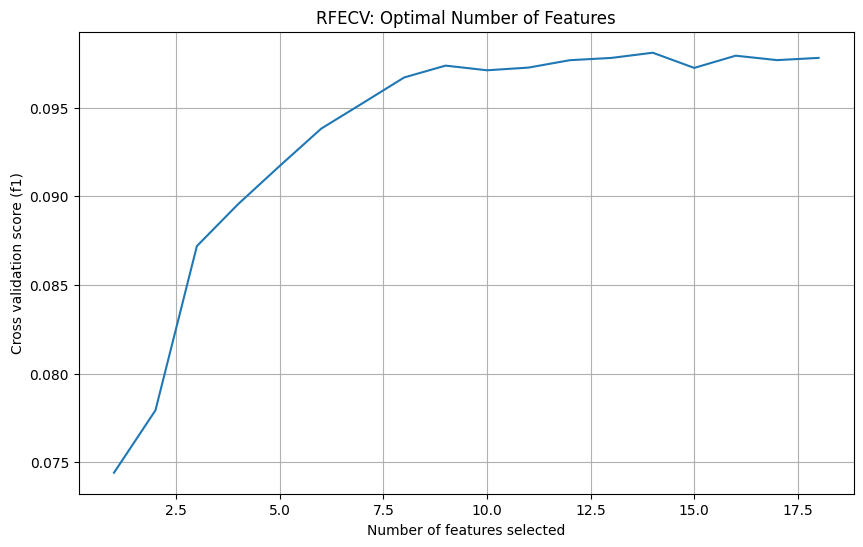

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# Re-initialize the XGBoost Classifier with the same parameters as model_new
# This ensures RFECV uses an estimator configured for our imbalanced data
rfe_estimator = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight_value_new # Use the scale_pos_weight calculated for the new data
)

# Create the RFE object
# We'll use StratifiedKFold for cross-validation to maintain the class distribution in each fold
# Scoring='f1' is a good metric for imbalanced datasets as it balances precision and recall
rfe = RFECV(
    estimator=rfe_estimator,
    step=1,          # Remove one feature at a time
    cv=StratifiedKFold(5), # 5-fold stratified cross-validation
    scoring='f1',    # Use F1-score for evaluation, which is suitable for imbalanced datasets
    min_features_to_select=1 # Keep at least one feature
)

print("Starting RFECV... This may take some time.")
# Fit RFE to the training data (X_train_new and y_train_new, without 'interest_rate_time')
rfe.fit(X_train_new, y_train_new)
print("RFECV completed.")

print(f"Optimal number of features: {rfe.n_features_}")
print("Selected features:")
selected_features = X_train_new.columns[rfe.support_].tolist()
print(selected_features)

# Plot number of features vs. cross-validation score
plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (f1)")
plt.plot(range(1, len(rfe.cv_results_['mean_test_score']) + 1), rfe.cv_results_['mean_test_score'])
plt.title("RFECV: Optimal Number of Features")
plt.grid(True)
plt.show()

### Retrain Model with Optimal Features

Now that we have identified the optimal set of features, we will train a final XGBoost model using only these features. This new model should be more robust and potentially more interpretable.

In [ ]:
# Create new training and testing sets with only the selected features
X_train_rfe = X_train_new[selected_features]
X_test_rfe = X_test_new[selected_features]

# Initialize and train the final XGBoost Classifier with optimal features
final_model_rfe = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight_value_new # Use the same scale_pos_weight
)

print("\nTraining the final XGBoost model with optimal RFE features...")
final_model_rfe.fit(X_train_rfe, y_train_new)
print("Final XGBoost model with RFE features training complete!")

# Evaluate the final model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_pred_rfe = final_model_rfe.predict(X_test_rfe)
y_pred_proba_rfe = final_model_rfe.predict_proba(X_test_rfe)[:, 1]

accuracy_rfe = accuracy_score(y_test_new, y_pred_rfe)
precision_rfe = precision_score(y_test_new, y_pred_rfe)
recall_rfe = recall_score(y_test_new, y_pred_rfe)
f1_rfe = f1_score(y_test_new, y_pred_rfe)
roc_auc_rfe = roc_auc_score(y_test_new, y_pred_proba_rfe)
conf_matrix_rfe = confusion_matrix(y_test_new, y_pred_rfe)

print(f"\nFinal Model Evaluation on Test Set (with RFE selected features):")
print(f"Accuracy: {accuracy_rfe:.4f}")
print(f"Precision: {precision_rfe:.4f}")
print(f"Recall: {recall_rfe:.4f}")
print(f"F1-Score: {f1_rfe:.4f}")
print(f"ROC AUC: {roc_auc_rfe:.4f}")
print(f"\nConfusion Matrix:\n{conf_matrix_rfe}")

# Display feature importances for the RFE selected model
feature_importances_rfe = final_model_rfe.feature_importances_
importance_df_rfe = pd.DataFrame({
    'Feature': selected_features,
    'Importance': feature_importances_rfe
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances of the final RFE selected model (Top 10):")
display(importance_df_rfe.head(10))


Training the final XGBoost model with optimal RFE features...
Final XGBoost model with RFE features training complete!

Final Model Evaluation on Test Set (with RFE selected features):
Accuracy: 0.7019
Precision: 0.0541
Recall: 0.6682
F1-Score: 0.1002
ROC AUC: 0.7559

Confusion Matrix:
[[85318 36088]
 [ 1026  2066]]

Feature Importances of the final RFE selected model (Top 10):


,Feature,Importance
4,LTV_time,0.175614
11,FICO_orig_time,0.111487
0,time,0.104518
13,Interest_Rate_orig_time,0.076355
2,mat_time,0.063301
3,balance_time,0.059742
5,gdp_time,0.058950
12,LTV_orig_time,0.057319
8,REtype_SF_orig_time,0.055980
10,balance_orig_time,0.051967


### Evaluate XGBoost Model Performance

After training the model, it's crucial to evaluate its performance on unseen data (the test set) to ensure it generalizes well. We will calculate several common classification metrics.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Model Evaluation on Test Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"\nConfusion Matrix:\n{conf_matrix}")

Model Evaluation on Test Set:
Accuracy: 0.9751
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC AUC: 0.7685

Confusion Matrix:
[[121402      4]
 [  3092      0]]


### Analyze Target Variable Distribution

The evaluation metrics strongly suggest a class imbalance issue. Let's inspect the distribution of our target variable, `default_time`, to confirm this.

In [ ]:
print("Distribution of 'default_time' in the training set:")
print(y_train.value_counts())
print("\nPercentage distribution:")
print(y_train.value_counts(normalize=True) * 100)

Distribution of 'default_time' in the training set:
default_time
0    485925
1     12066
Name: count, dtype: int64

Percentage distribution:
default_time
0    97.577065
1     2.422935
Name: proportion, dtype: float64


The `raw` DataFrame has now been updated with the data from `mortgage.csv`. You may need to re-run previous data preparation and splitting steps if the new dataset has a different structure or requires different preprocessing.